机器学习的一般过程有 数据收集->数据清洗->特征工程->模型选择->模型评估

数据收集数据清洗模型选择先略过

以下为特征工程

1.1特征选择方法

In [ ]:
import numpy as np
import pandas as pd
a = np.random.randn(100)  # 随机生产100个数据
print(np.var(a))          # 打印数据方差

0.8641293427065978


In [4]:
# import numpy as np
b=np.random.randn(100)*0.1
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
print(np.var(b))

0.005708391651433921


低方差过滤法（特征选择法之一）
对于特征的选择，可以直接基于方差来判断，这是最简单的。低方差的特征意味着该特征的所有样本值几乎相同，对预测影响极小，可以将其去掉。

In [5]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
# 构造特征向量
a = np.random.randn(100)  # 随机生产100个数据
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
x=np.vstack((a,b)).T
print(np.var(a))
# print(a)
print(np.var(b))
# print(b)
# print(x)  # 打印特征向量
print(x.shape)  # 打印特征向量的形状
vt=VarianceThreshold(threshold=0.01)  # 设置方差阈值为0.01
x_filterd=vt.fit_transform(x)  # 进行特征选择
# print(x_filterd)  # 打印选择后的特征向量
print(x_filterd.shape)  # 打印选择后的特征向量的形状

0.8195670947653595
0.013852975198387286
(100, 2)
(100, 2)


相关系数法（特征选择法之二）
通过计算特征与目标变量或特征之间的相关性，筛选出高相关性特征（与目标相关）或剔除冗余特征（特征间高度相关）。

[](./ml_img/皮尔逊.png)

In [6]:
# 皮尔逊相关系数用于衡量两个变量的线性相关性，取值范围[−1,1]。
import pandas as pd
advertising = pd.read_csv('./data/advertising.csv')  # 读取数据
# print(advertising.head())  # 打印数据的前5行
# print(advertising.shape)
# 数据预处理
#第一个参数是删除行第一个元素，第二个参数对每行做操作，第三个参数原地操作
advertising.drop(advertising.columns[0], axis=1, inplace=True)
# print(advertising.head())  # 打印数据的前5行
# 去掉空值
advertising.dropna(inplace=True)
# 取出特征和标签
X = advertising.drop('Sales', axis=1)  # 特征
y = advertising['Sales']  # 标签
# print(X.head())  # 打印特征的前5行
# print(y.head())  # 打印标签的前5行
# 计算特征与标签之间的相关系数
print(X.corrwith(y,method='pearson'))  # 打印特征与标签之间的相关系数

TV           0.782224
Radio        0.576223
Newspaper    0.228299
dtype: float64


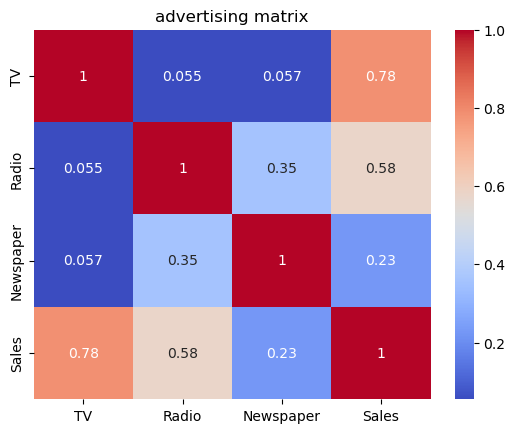

In [7]:
# 计算相关系数矩阵并画出热力图
corr_matrix = advertising.corr(method='pearson')  # 计算相关系数矩阵
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # 画出热力图
plt.title('advertising matrix')
plt.show()  # 显示图像

斯皮尔曼相关系数（第二种相关系数）


![](./ml_img/斯皮尔曼.png)

In [8]:
# 斯皮尔曼相关系数的应用
import pandas as pd
x = [55,65,70,75,85,50,60,72,80,58]
y = [[5],[8],[10],[12],[15],[3],[7],[9],[14],[6]]
Y = pd.DataFrame(y)
# print(y)
# print(Y)
X = pd.Series(x)
# print(x)
# print(X)
print(Y.corrwith(X,method='spearman'))  # 打印斯皮尔曼相关系数

0    0.987879
dtype: float64


1.2特征转换法

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

np.random.seed(42)
data = np.abs(np.random.randn(6, 1) * 10) + 1  # 模拟一列正偏态数据

# ① 标准化（Z-score）：均值为0，标准差为1，适合正态分布数据
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data)
print("原始数据:   ", data.flatten().round(2))
print("标准化结果: ", data_std.flatten().round(2))

# ② 归一化（Min-Max）：缩放到 [0, 1]，适合边界明确的特征
scaler_mm = MinMaxScaler()
data_mm = scaler_mm.fit_transform(data)
print("归一化结果: ", data_mm.flatten().round(2))

# ③ 对数变换：压缩右偏分布（如收入、销量），要求数据 > 0
data_log = np.log1p(data)  # log(1 + x) 避免 log(0)
print("对数变换结果:", data_log.flatten().round(2))

# ④ 类别编码
colors = np.array(['red', 'blue', 'green', 'blue', 'red', 'green'])
# Label Encoding：将类别映射为整数（适合有序类别或树模型）
le = LabelEncoder()
colors_le = le.fit_transform(colors)
print("\n类别标签:   ", colors)
print("Label编码:  ", colors_le)  # blue=0, green=1, red=2

# One-Hot Encoding：每个类别独立一列，避免数值大小带来的顺序假设
ohe = OneHotEncoder(sparse_output=False)
colors_ohe = ohe.fit_transform(colors.reshape(-1, 1))
print("One-Hot编码:\n", colors_ohe)

原始数据:    [ 5.97  2.38  7.48 16.23  3.34  3.34]
标准化结果:  [-0.1  -0.87  0.22  2.08 -0.66 -0.66]
归一化结果:  [0.26 0.   0.37 1.   0.07 0.07]
对数变换结果: [1.94 1.22 2.14 2.85 1.47 1.47]

类别标签:    ['red' 'blue' 'green' 'blue' 'red' 'green']
Label编码:   [2 0 1 0 2 1]
One-Hot编码:
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


1.3特征构造法

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer

np.random.seed(0)
df = pd.DataFrame({
    'price': np.random.randint(50, 200, 6),
    'quantity': np.random.randint(1, 20, 6),
    'age': np.random.randint(18, 60, 6),
})
print("原始特征:\n", df)

# ① 交叉特征（手动构造）：用业务逻辑组合两列，产生更有意义的新特征
df['revenue'] = df['price'] * df['quantity']  # 收入 = 单价 × 数量
df['price_per_age'] = df['price'] / df['age']  # 每岁花费（消费能力指标）
print("\n加入交叉特征:\n", df)

# ② 多项式特征（自动构造）：生成原始特征的高次项与交叉项
# degree=2 会生成 x1, x2, x1², x1*x2, x2²
X = df[['price', 'quantity']].values
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['price', 'quantity']))
print("\n多项式特征（degree=2）:\n", poly_df)

# ③ 分箱（Binning）：将连续特征离散化，捕捉非线性关系
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
age_binned = kbd.fit_transform(df[['age']])
df['age_bin'] = age_binned.astype(int)  # 0=低龄 1=中龄 2=高龄
print("\n年龄分箱结果:\n", df[['age', 'age_bin']])

原始特征:
    price  quantity  age
0     97        19   57
1    167         5   41
2    117         7   42
3    153        13   35
4     59         2   55
5     71         7   43

加入交叉特征:
    price  quantity  age  revenue  price_per_age
0     97        19   57     1843       1.701754
1    167         5   41      835       4.073171
2    117         7   42      819       2.785714
3    153        13   35     1989       4.371429
4     59         2   55      118       1.072727
5     71         7   43      497       1.651163

多项式特征（degree=2）:
    price  quantity  price^2  price quantity  quantity^2
0   97.0      19.0   9409.0          1843.0       361.0
1  167.0       5.0  27889.0           835.0        25.0
2  117.0       7.0  13689.0           819.0        49.0
3  153.0      13.0  23409.0          1989.0       169.0
4   59.0       2.0   3481.0           118.0         4.0
5   71.0       7.0   5041.0           497.0        49.0

年龄分箱结果:
    age  age_bin
0   57        2
1   41        0
2   42    

1.4pca特征降维

主成分分析（PCA）
是一种常用的降维技术，通过线性变换将高维数据投影到低维空间，同时保留数据的主要变化模式。

使用sklearn.decomposition.PCA进行主成分分析。参数n_components若为小数则表示保留多少比例的信息，为整数则表示保留多少个维度。

(1000, 2)


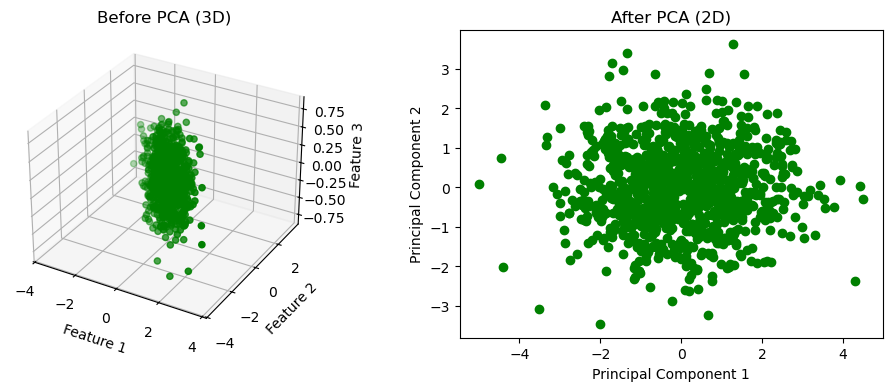

In [11]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
num_number = 1000 #每组特征生产数量
col1 = np.random.normal(loc=0, scale=1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据
col2 = np.random.normal(loc=0, scale=0.2, size=num_number)  # 生产1000个均值为0，标准差为0.1的随机数据
noise = np.random.normal(loc=0, scale=0.1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据,作为噪声
X = np.vstack([col1+col2,col2-col1,col2+noise]).T  # 将三列特征组合成一个特征矩阵
# 标准化
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)
print(X_pca.shape)  # 打印降维后的特征矩阵的形状
# 可视化
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121, projection="3d")
#print(X.shape)# 打印原始特征矩阵的形状
ax1.scatter(X[:, 0], X[:, 1], X[:,2], c="g")
ax1.set_title("Before PCA (3D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_zlabel("Feature 3")
# 转换后的2维数据可视化
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c="g")
ax2.set_title("After PCA (2D)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
plt.show()

损失函数用来判断预测结果和真实结果的偏差
损失函数本质是模型参数的函数

![](./ml_img/损失函数1.png)
![](./ml_img/损失函数2.png)

## 2. 欠拟合与过拟合（Underfitting & Overfitting）

模型复杂度影响**偏差（Bias）**与**方差（Variance）**的平衡：

| 状态 | 训练误差 | 测试误差 | 原因 | 解决方法 |
|------|----------|----------|------|---------|
| **欠拟合** | 高 | 高 | 模型太简单，无法捕捉规律（高偏差） | 增加特征/提高模型复杂度 |
| **合适** | 低 | 低 | 偏差与方差均衡 | — |
| **过拟合** | 低 | 高 | 模型太复杂，死记训练集（高方差） | 正则化、增加数据、降低复杂度 |

**偏差-方差权衡（Bias-Variance Tradeoff）**：

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}$$

模型越简单 → 偏差越高；模型越复杂 → 方差越高。目标是找到二者的最优平衡点。

C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 27424 (\N{CJK UNIFIED IDEOGRAPH-6B20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:35: UserWarning: Glyph 30495 (\

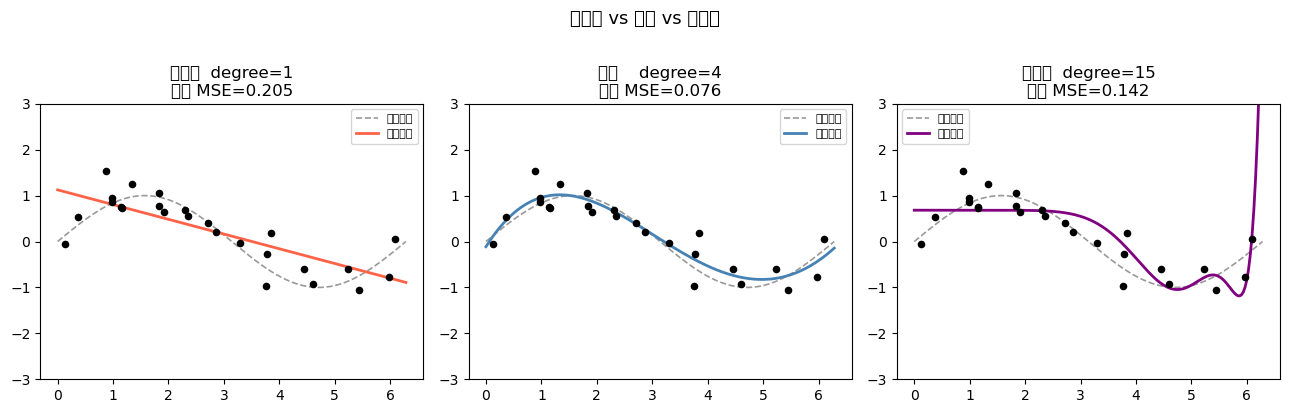

C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\3287171585.py:58: UserWarning: Glyph 20559 (\

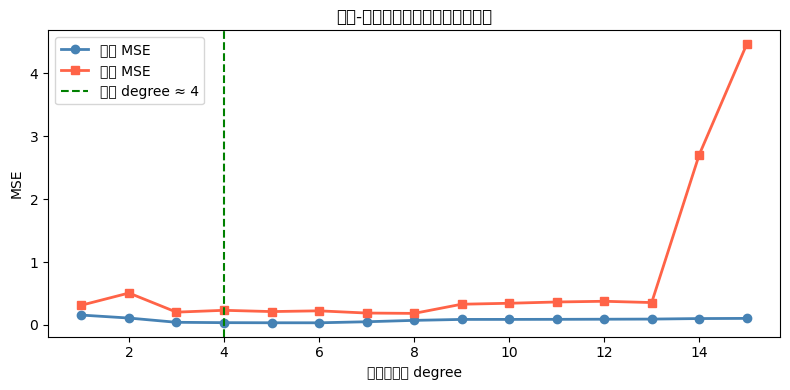

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 生成真实关系为 sin(x) 的数据，样本量少（容易过拟合）
np.random.seed(42)
x_uf = np.sort(np.random.uniform(0, 2 * np.pi, 25))
y_uf = np.sin(x_uf) + np.random.randn(25) * 0.3
x_test_uf = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
settings = [
    (1,  '欠拟合  degree=1',  'tomato'),
    (4,  '合适    degree=4',  'steelblue'),
    (15, '过拟合  degree=15', 'purple'),
]

for ax, (degree, title, color) in zip(axes, settings):
    pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipe.fit(x_uf.reshape(-1, 1), y_uf)
    y_fit  = pipe.predict(x_test_uf.reshape(-1, 1))
    tr_mse = mean_squared_error(y_uf, pipe.predict(x_uf.reshape(-1, 1)))
    ax.scatter(x_uf, y_uf, color='black', s=20, zorder=5)
    ax.plot(x_test_uf, np.sin(x_test_uf), 'k--', linewidth=1.2, alpha=0.4, label='真实曲线')
    ax.plot(x_test_uf, y_fit, color=color, linewidth=2, label=f'拟合曲线')
    ax.set_ylim(-3, 3)
    ax.set_title(f'{title}\n训练 MSE={tr_mse:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('欠拟合 vs 合适 vs 过拟合', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 验证集 MSE 随多项式次数变化
degrees = range(1, 16)
tr_mses, te_mses = [], []
x_tr2, x_te2, y_tr2, y_te2 = train_test_split(
    x_uf.reshape(-1, 1), y_uf, test_size=0.3, random_state=0)

for d in degrees:
    p = make_pipeline(PolynomialFeatures(d), LinearRegression())
    p.fit(x_tr2, y_tr2)
    tr_mses.append(mean_squared_error(y_tr2, p.predict(x_tr2)))
    te_mses.append(mean_squared_error(y_te2, p.predict(x_te2)))

plt.figure(figsize=(8, 4))
plt.plot(degrees, tr_mses, 'o-', color='steelblue', linewidth=2, label='训练 MSE')
plt.plot(degrees, te_mses, 's-', color='tomato',    linewidth=2, label='测试 MSE')
plt.axvline(4, color='green', linestyle='--', linewidth=1.5, label='最优 degree ≈ 4')
plt.xlabel('多项式阶数 degree')
plt.ylabel('MSE')
plt.title('偏差-方差权衡：随模型复杂度变化')
plt.legend()
plt.tight_layout()
plt.show()

## 3. 正则化（Regularization）

过拟合的根本原因是模型权重过大（对训练数据"死记硬背"）。正则化通过在损失函数中加入**惩罚项**约束权重：

| 方法 | 损失函数 | 效果 |
|------|----------|------|
| **Ridge（L2）** | $J + \alpha \|\mathbf{w}\|_2^2$ | 权重整体缩小，保留所有特征 |
| **Lasso（L1）** | $J + \alpha \|\mathbf{w}\|_1$ | 部分权重归零，自动特征选择 |
| **ElasticNet** | $J + \alpha_1\|\mathbf{w}\|_1 + \alpha_2\|\mathbf{w}\|_2^2$ | L1 + L2 组合 |

`alpha`（正则化强度）是超参数：**alpha 越大，模型越保守，偏差↑ 方差↓**。

**如何选 alpha？** → 用交叉验证（见第 4 节）在验证集上搜索最优值。

C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\880141944.py:34: UserWarning: Glyph 65306 (\N{FULL

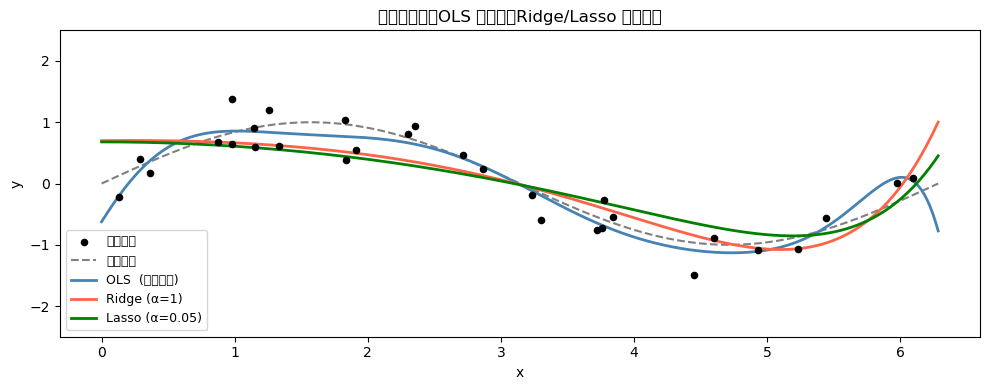

Lasso 非零权重数量：2 / 11


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(42)
x_reg = np.sort(np.random.uniform(0, 2 * np.pi, 30))
y_reg = np.sin(x_reg) + np.random.randn(30) * 0.3
x_plot = np.linspace(0, 2 * np.pi, 300)

# ── 正则化对比：OLS vs Ridge vs Lasso（d=10 多项式特征） ─────────
models_reg = {
    'OLS  (无正则化)': make_pipeline(PolynomialFeatures(10), StandardScaler(), LinearRegression()),
    'Ridge (α=1)':    make_pipeline(PolynomialFeatures(10), StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (α=0.05)': make_pipeline(PolynomialFeatures(10), StandardScaler(),
                                    Lasso(alpha=0.05, max_iter=10000)),
}

plt.figure(figsize=(10, 4))
plt.scatter(x_reg, y_reg, color='black', s=20, zorder=5, label='训练数据')
plt.plot(x_plot, np.sin(x_plot), 'k--', linewidth=1.5, alpha=0.5, label='真实曲线')

for (name, mdl), color in zip(models_reg.items(), ['steelblue', 'tomato', 'green']):
    mdl.fit(x_reg.reshape(-1, 1), y_reg)
    plt.plot(x_plot, mdl.predict(x_plot.reshape(-1, 1)),
             color=color, linewidth=2, label=name)

plt.ylim(-2.5, 2.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('正则化效果：OLS 过拟合，Ridge/Lasso 抑制震荡')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 权重稀疏性展示 ───────────────────────────────────────────────
lasso_pipe = make_pipeline(PolynomialFeatures(10), StandardScaler(),
                           Lasso(alpha=0.05, max_iter=10000))
lasso_pipe.fit(x_reg.reshape(-1, 1), y_reg)
lasso_coefs = lasso_pipe.named_steps['lasso'].coef_
print(f"Lasso 非零权重数量：{np.sum(lasso_coefs != 0)} / {len(lasso_coefs)}")

## 4. 交叉验证（Cross-Validation）

直接用一次 train/test split 评估模型，结果依赖随机划分，不稳定。**K 折交叉验证**把数据分成 K 份，轮流用 K-1 份训练、1 份验证，取 K 次得分均值：

$$\text{CV Score} = \frac{1}{K} \sum_{k=1}^{K} \text{score}_k$$

| 方法 | 说明 | 适用场景 |
|------|------|---------|
| **K-Fold** | 数据等分为 K 折，轮流验证 | 最常用，K=5 或 10 |
| **Stratified K-Fold** | 分层保持各类比例 | 分类任务（类别不均衡） |
| **Leave-One-Out (LOO)** | K = 样本总数 | 小数据集 |

**学习曲线（Learning Curve）**：随训练样本增加，观察训练/验证得分变化，可诊断欠拟合与过拟合：
- 训练得分高、验证得分低，差距大 → **过拟合**
- 训练和验证得分都低 → **欠拟合**
- 差距小且都高 → 模型合适

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_diabetes

# 使用糖尿病数据集演示交叉验证
X_dia, y_dia = load_diabetes(return_X_y=True)

# ── K 折交叉验证 ────────────────────────────────────────────────
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
model_cv = Ridge(alpha=1.0)

fold_scores = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_dia), 1):
    model_cv.fit(X_dia[tr_idx], y_dia[tr_idx])
    score = model_cv.score(X_dia[te_idx], y_dia[te_idx])  # R²
    fold_scores.append(score)
    print(f"Fold {fold}: R² = {score:.4f}")

print(f"\n平均 R² = {np.mean(fold_scores):.4f}  ±  {np.std(fold_scores):.4f}")

# ── cross_val_score 快捷方式 ─────────────────────────────────────
scores_quick = cross_val_score(Ridge(alpha=1.0), X_dia, y_dia, cv=5, scoring='r2')
print(f"\ncross_val_score 结果: {scores_quick.round(4)}")
print(f"均值 ± 标准差: {scores_quick.mean():.4f} ± {scores_quick.std():.4f}")

# ── 学习曲线：判断欠拟合/过拟合 ─────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=1.0), X_dia, y_dia,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2')

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', linewidth=2, label='训练集 R²')
plt.plot(train_sizes, val_mean,   's-', color='tomato',    linewidth=2, label='验证集 R²（CV）')
plt.fill_between(train_sizes,
                 train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
plt.fill_between(train_sizes,
                 val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='tomato')
plt.xlabel('训练样本数')
plt.ylabel('R²')
plt.title('学习曲线（Learning Curve）')
plt.legend()
plt.tight_layout()
plt.show()

## 5. 模型评估指标

### 5.1 回归任务指标

| 指标 | 公式 | 含义 |
|------|------|------|
| **MSE** | $\frac{1}{m}\sum(\hat{y}-y)^2$ | 均方误差，对大误差敏感 |
| **RMSE** | $\sqrt{\text{MSE}}$ | 与目标量纲相同，直观可读 |
| **MAE** | $\frac{1}{m}\sum|\hat{y}-y|$ | 平均绝对误差，对异常值鲁棒 |
| **R²** | $1 - \frac{\sum(\hat{y}-y)^2}{\sum(\bar{y}-y)^2}$ | 决定系数，越接近 1 越好 |

### 5.2 分类任务指标

混淆矩阵：

|  | 预测正 | 预测负 |
|--|--------|--------|
| **实际正** | TP（真正例） | FN（假负例） |
| **实际负** | FP（假正例） | TN（真负例） |

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}, \quad \text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}$$

$$F1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**ROC-AUC**：绘制 TPR vs FPR 曲线，AUC 越接近 1 越好；AUC=0.5 相当于随机猜测。

准确率  Accuracy  = 0.9737
精确率  Precision = 0.9722  （预测为正中有多少真正是正）
召回率  Recall    = 0.9859  （实际正例中有多少被找出）
F1 分数           = 0.9790  （Precision 与 Recall 的调和均值）
AUC-ROC           = 0.9974  （ROC 曲线下面积）


C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_70996\2479429748.py:56: UserWarning: Glyph 23454 (\

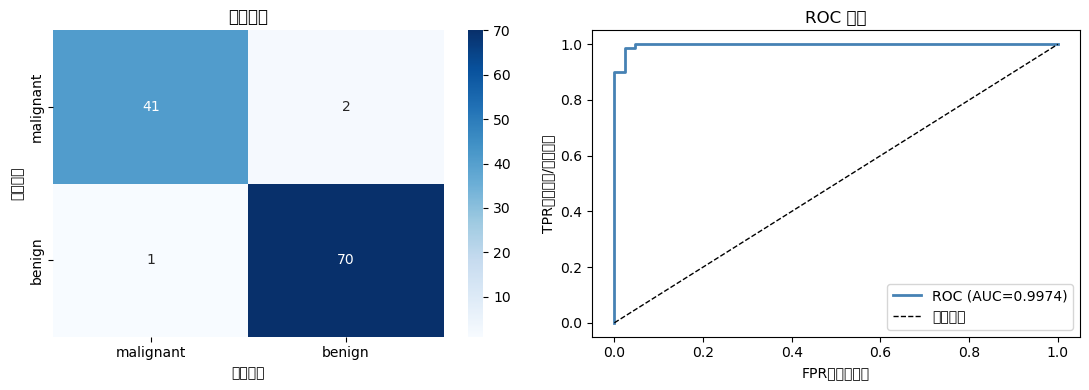

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_tr_s, y_tr)
y_pred = clf.predict(X_te_s)
y_prob = clf.predict_proba(X_te_s)[:, 1]

acc  = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec  = recall_score(y_te, y_pred)
f1   = f1_score(y_te, y_pred)
auc  = roc_auc_score(y_te, y_prob)

print(f"准确率  Accuracy  = {acc:.4f}")
print(f"精确率  Precision = {prec:.4f}  （预测为正中有多少真正是正）")
print(f"召回率  Recall    = {rec:.4f}  （实际正例中有多少被找出）")
print(f"F1 分数           = {f1:.4f}  （Precision 与 Recall 的调和均值）")
print(f"AUC-ROC           = {auc:.4f}  （ROC 曲线下面积）")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 混淆矩阵
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')
axes[0].set_title('混淆矩阵')

# ROC 曲线
fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
axes[1].set_xlabel('FPR（假正率）')
axes[1].set_ylabel('TPR（真正率/召回率）')
axes[1].set_title('ROC 曲线')
axes[1].legend()

plt.tight_layout()
plt.show()